KROK 1: Pobieranie danych z giełdy i analiza statystyczna

Pobieram dane BTC/USDT (1h)...

Pobrano 8992 unikalnych świec. Zakres: 2024-01-01 00:00:00 → 2025-01-09 15:00:00
Po oczyszczeniu: 8801 rekordów

Rozkład klas:
Target_Signal
0.0    4646
1.0    2278
2.0    1877
Name: count, dtype: int64


,Czas,Open,High,Low,Close,Volume,RSI,Target_Signal
0,2024-01-07 23:00:00,43865.7,44019.8,43600.0,43926.6,208.403795,49.675157,1.0
1,2024-01-08 00:00:00,43926.7,43981.9,43625.7,43630.7,165.360681,42.616738,1.0
2,2024-01-08 01:00:00,43630.7,43804.0,43610.0,43712.1,106.680380,42.007113,1.0
3,2024-01-08 02:00:00,43712.2,43801.3,43183.5,43372.9,289.832068,35.743629,1.0
4,2024-01-08 03:00:00,43359.5,43559.4,43227.0,43517.2,174.149746,30.951871,1.0
5,2024-01-08 04:00:00,43517.1,43606.9,43430.0,43602.7,128.585911,33.477017,1.0
6,2024-01-08 05:00:00,43602.7,43649.0,43476.0,43640.4,113.822358,40.270566,1.0
7,2024-01-08 06:00:00,43640.4,44328.6,43591.6,43910.7,609.540504,49.828056,1.0
8,2024-01-08 07:00:00,43910.2,44072.9,43792.0,43973.7,118.075550,47.993148,1.0
9,2024-01-08 08:00:00,43973.7,44067.3,43853.1,43870.5,66.452502,44.755213,1.0


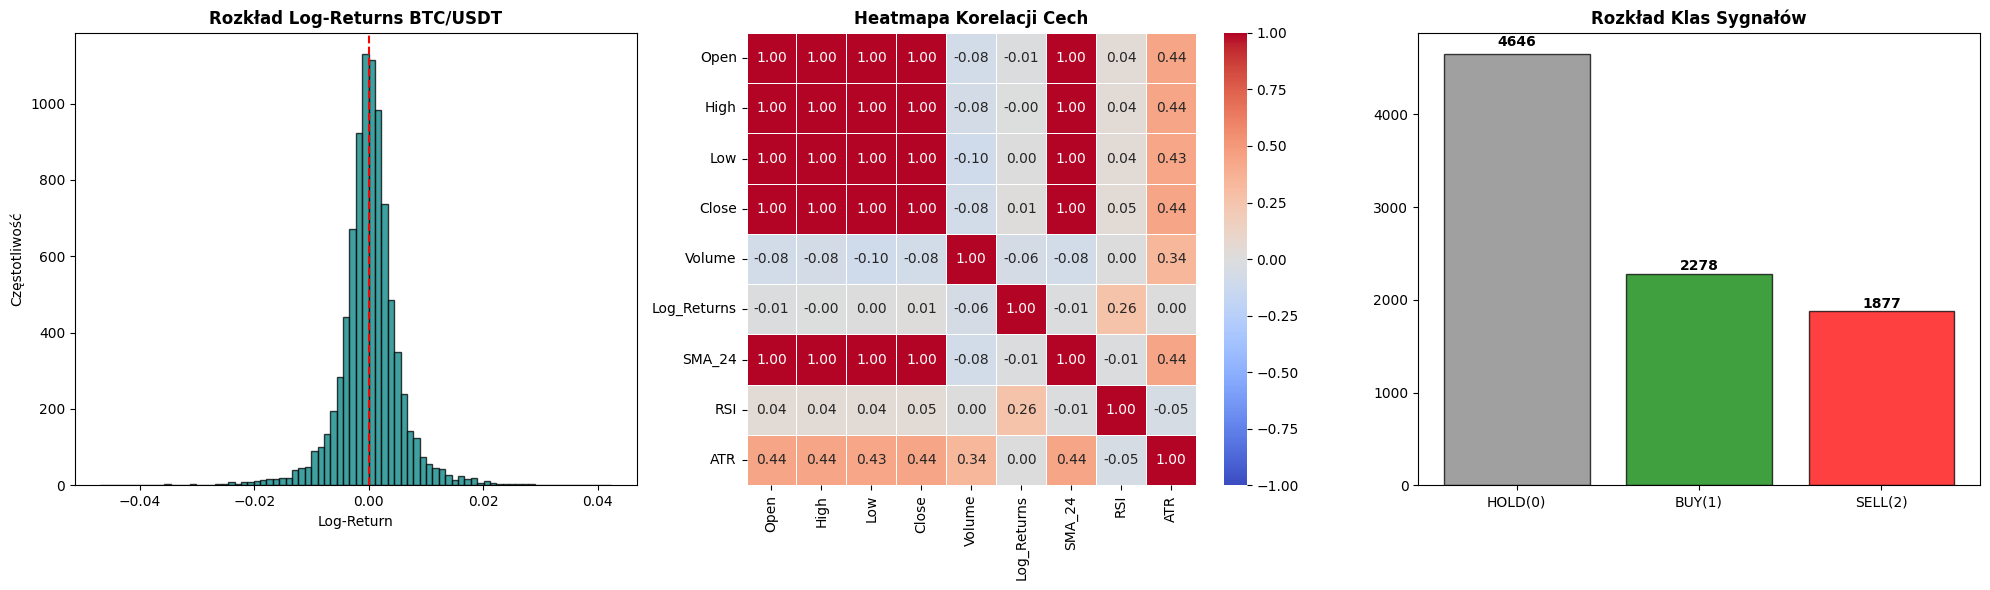


--- KROK 1 ZAKOŃCZONY ---


In [84]:
!pip install ccxt -q
import ccxt, pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, time

print("="*70)
print("KROK 1: Pobieranie danych z giełdy i analiza statystyczna")
print("="*70)

# POBIERANIE DANYCH
gielda = ccxt.kucoin()
symbol = 'BTC/USDT'
LIMIT_DOCELOWY = 8000

all_candles = []
since = gielda.parse8601('2024-01-01T00:00:00Z')

print(f"\nPobieram dane {symbol} (1h)...")
while len(all_candles) < LIMIT_DOCELOWY:
    batch = gielda.fetch_ohlcv(symbol, '1h', since=since, limit=1000)
    if not batch: break
    all_candles.extend(batch)
    since = batch[-1][0] + 1
    print(f"  Pobrano: {len(all_candles)} świec", end='\r')
    time.sleep(0.3)

df = pd.DataFrame(all_candles, columns=['Czas','Open','High','Low','Close','Volume'])
df = df.drop_duplicates(subset='Czas').sort_values('Czas').reset_index(drop=True)
df['Czas'] = pd.to_datetime(df['Czas'], unit='ms')
print(f"\nPobrano {len(df)} unikalnych świec. Zakres: {df['Czas'].iloc[0]} → {df['Czas'].iloc[-1]}")

# OHLCV + wskaźniki
df['Log_Returns'] = np.log(df['Close'] / df['Close'].shift(1))
df['SMA_24'] = df['Close'].rolling(24).mean()
df['SMA_168'] = df['Close'].rolling(168).mean()

# RSI
delta = df['Close'].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss_s = (-delta.clip(upper=0)).rolling(14).mean()
df['RSI'] = 100 - (100 / (1 + gain / loss_s))

# ATR
tr = pd.concat([
    df['High'] - df['Low'],
    (df['High'] - df['Close'].shift(1)).abs(),
    (df['Low']  - df['Close'].shift(1)).abs()
], axis=1).max(axis=1)
df['ATR'] = tr.rolling(14).mean()


HORYZONT = 24
df['Cena_za_24h'] = df['Close'].shift(-HORYZONT)

def wylicz_sygnal(w):
    if pd.isna(w['Cena_za_24h']): return np.nan
    zmiana = (w['Cena_za_24h'] - w['Close']) / w['Close']
    if zmiana > 0.015: return 1    # BUY
    elif zmiana < -0.015: return 2  # SELL
    return 0                        # HOLD

df['Target_Signal'] = df.apply(wylicz_sygnal, axis=1)
df = df.dropna().reset_index(drop=True)

print(f"Po oczyszczeniu: {len(df)} rekordów")
print(f"\nRozkład klas:\n{df['Target_Signal'].value_counts().sort_index()}")

#PODGLĄD
display(df[['Czas','Open','High','Low','Close','Volume','RSI','Target_Signal']].head(10))

#WIZUALIZACJA
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].hist(df['Log_Returns'], bins=80, color='teal', edgecolor='black', alpha=0.75)
axes[0].set_title("Rozkład Log-Returns BTC/USDT", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Log-Return"); axes[0].set_ylabel("Częstotliwość")
axes[0].axvline(x=0, color='red', linestyle='--')

cechy_kor = ['Open','High','Low','Close','Volume','Log_Returns','SMA_24','RSI','ATR']
sns.heatmap(df[cechy_kor].corr(), annot=True, cmap='coolwarm', fmt=".2f",
            linewidths=0.5, vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Heatmapa Korelacji Cech", fontsize=12, fontweight='bold')

klasy = df['Target_Signal'].value_counts().sort_index()
axes[2].bar(['HOLD(0)','BUY(1)','SELL(2)'], klasy.values,
            color=['gray','green','red'], edgecolor='black', alpha=0.75)
axes[2].set_title("Rozkład Klas Sygnałów", fontsize=12, fontweight='bold')
for i, v in enumerate(klasy.values):
    axes[2].text(i, v+(v*0.02), str(v), ha='center', fontweight='bold')

plt.tight_layout(); plt.show()
print("\n--- KROK 1 ZAKOŃCZONY ---")


KROK 2: Sliding Window + Normalizacja
Features (10): ['Open', 'High', 'Low', 'Close', 'Volume', 'Log_Returns', 'SMA_24', 'SMA_168', 'RSI', 'ATR']
Wygenerowano 2153 sekwencji
Train: 1507, Val: 323, Test: 323


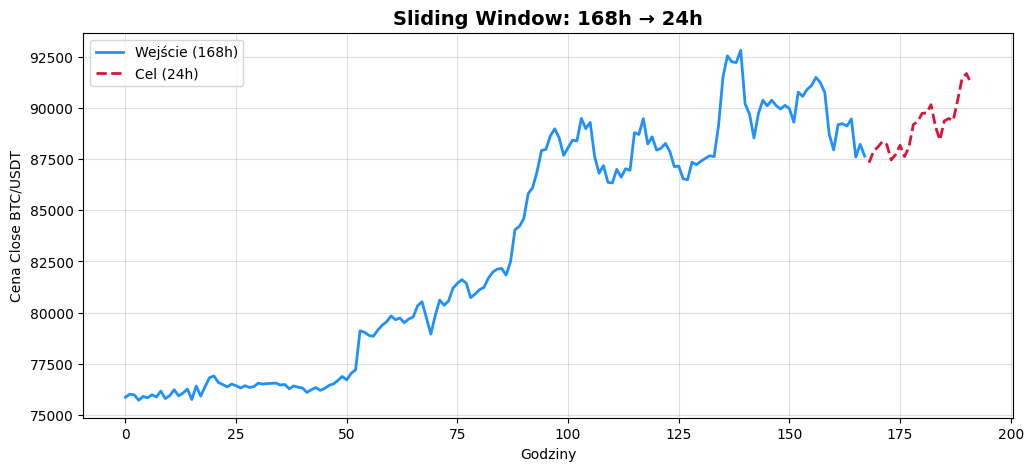


Tensory: X=torch.Size([1507, 168, 10]), Y_reg=torch.Size([1507, 24]), Y_clf=torch.Size([1507])
--- KROK 2 ZAKOŃCZONY ---


In [85]:
from sklearn.preprocessing import RobustScaler
import numpy as np, torch, matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

print("="*70)
print("KROK 2: Sliding Window + Normalizacja")
print("="*70)

#PARAMETRY
ROZMIAR_OKNA = 168   # 7 dni wstecz
HORYZONT = 24        # 24h w przód
PRZESUNIECIE = 4     # krok co 4h
BATCH_SIZE = 32

# OHLCV + wskaźniki
features = ['Open','High','Low','Close','Volume','Log_Returns','SMA_24','SMA_168','RSI','ATR']
NUM_FEATURES = len(features)
# Indeks kolumny Close w tablicy features
CLOSE_IDX = features.index('Close')

print(f"Features ({NUM_FEATURES}): {features}")

# SLIDING WINDOW
X_surowe, Y_reg_surowe, Y_clf_surowe = [], [], []

for i in range(0, len(df) - ROZMIAR_OKNA - HORYZONT, PRZESUNIECIE):
    X_surowe.append(df[features].iloc[i : i+ROZMIAR_OKNA].values)
    Y_reg_surowe.append(df['Close'].iloc[i+ROZMIAR_OKNA : i+ROZMIAR_OKNA+HORYZONT].values)
    Y_clf_surowe.append(df['Target_Signal'].iloc[i+ROZMIAR_OKNA-1])

X_surowe = np.array(X_surowe)
Y_reg_surowe = np.array(Y_reg_surowe)
Y_clf_surowe = np.array(Y_clf_surowe, dtype=np.int64)
print(f"Wygenerowano {len(X_surowe)} sekwencji")

total = len(X_surowe)
t1, t2 = int(total*0.70), int(total*0.85)

X_train, X_val, X_test = X_surowe[:t1], X_surowe[t1:t2], X_surowe[t2:]
Y_reg_train, Y_reg_val, Y_reg_test = Y_reg_surowe[:t1], Y_reg_surowe[t1:t2], Y_reg_surowe[t2:]
Y_clf_train, Y_clf_val, Y_clf_test = Y_clf_surowe[:t1], Y_clf_surowe[t1:t2], Y_clf_surowe[t2:]
print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

# STANDARYZACJA
scaler_X = RobustScaler()
X_train_sc = scaler_X.fit_transform(X_train.reshape(-1, NUM_FEATURES)).reshape(X_train.shape)
X_val_sc   = scaler_X.transform(X_val.reshape(-1, NUM_FEATURES)).reshape(X_val.shape)
X_test_sc  = scaler_X.transform(X_test.reshape(-1, NUM_FEATURES)).reshape(X_test.shape)

scaler_Y = RobustScaler()
Y_reg_train_sc = scaler_Y.fit_transform(Y_reg_train.reshape(-1,1)).reshape(Y_reg_train.shape)
Y_reg_val_sc   = scaler_Y.transform(Y_reg_val.reshape(-1,1)).reshape(Y_reg_val.shape)
Y_reg_test_sc  = scaler_Y.transform(Y_reg_test.reshape(-1,1)).reshape(Y_reg_test.shape)

#TENSORY + DATALOADERY
X_train_t = torch.tensor(X_train_sc, dtype=torch.float32)
Y_reg_train_t = torch.tensor(Y_reg_train_sc, dtype=torch.float32)
Y_clf_train_t = torch.tensor(Y_clf_train, dtype=torch.long)

X_val_t = torch.tensor(X_val_sc, dtype=torch.float32)
Y_reg_val_t = torch.tensor(Y_reg_val_sc, dtype=torch.float32)
Y_clf_val_t = torch.tensor(Y_clf_val, dtype=torch.long)

X_test_t = torch.tensor(X_test_sc, dtype=torch.float32)
Y_reg_test_t = torch.tensor(Y_reg_test_sc, dtype=torch.float32)
Y_clf_test_t = torch.tensor(Y_clf_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, Y_reg_train_t, Y_clf_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, Y_reg_val_t, Y_clf_val_t), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_t, Y_reg_test_t, Y_clf_test_t), batch_size=BATCH_SIZE, shuffle=False)

# WIZUALIZACJA
plt.figure(figsize=(12, 5))
plt.plot(range(ROZMIAR_OKNA), X_test[0, :, CLOSE_IDX], label="Wejście (168h)", color="dodgerblue", linewidth=2)
plt.plot(range(ROZMIAR_OKNA, ROZMIAR_OKNA+HORYZONT), Y_reg_test[0], label="Cel (24h)", color="crimson", linewidth=2, linestyle='--')
plt.title("Sliding Window: 168h → 24h", fontsize=14, fontweight='bold')
plt.xlabel("Godziny"); plt.ylabel("Cena Close BTC/USDT")
plt.legend(); plt.grid(alpha=0.4); plt.show()

print(f"\nTensory: X={X_train_t.shape}, Y_reg={Y_reg_train_t.shape}, Y_clf={Y_clf_train_t.shape}")
print("--- KROK 2 ZAKOŃCZONY ---")


In [119]:
import torch, torch.nn as nn, math

print("="*70)
print("KROK 3: Budowa architektury Transformer")
print("="*70)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe)
    def forward(self, x):
        return x + self.pe[:x.size(1), :]


class TransformerForecaster(nn.Module):
    """
    Hybrydowy Transformer z dwoma głowami (Multi-task Learning):
    - head_reg: predykcja ceny na 'horizon' kroków (regresja)
    - head_clf: sygnał BUY/SELL/HOLD (klasyfikacja)
    """
    def __init__(self, num_features=10, d_model=64, nhead=4, num_layers=2,
                 dropout=0.2, horizon=24, num_classes=3):
        super().__init__()
        self.input_proj = nn.Linear(num_features, d_model)
        self.pos_enc = PositionalEncoding(d_model)
        self.drop = nn.Dropout(dropout)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model*4,
            dropout=dropout, batch_first=True, activation="gelu"
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        self.head_reg = nn.Sequential(
            nn.Linear(d_model, d_model*2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model*2, horizon)
        )
        self.head_clf = nn.Sequential(
            nn.Linear(d_model, d_model), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model, num_classes)
        )
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1: nn.init.xavier_uniform_(p)

    def forward(self, src):
        x = self.drop(self.pos_enc(self.input_proj(src)))
        x = self.encoder(x)
        s = x.mean(dim=1)
        return self.head_reg(s), self.head_clf(s)


# FUNKCJA TWORZĄCA MODEL
def create_model(num_features=NUM_FEATURES, d_model=64, nhead=4,
                 num_layers=2, dropout=0.2, horizon=HORYZONT):
    return TransformerForecaster(
        num_features=num_features, d_model=d_model, nhead=nhead,
        num_layers=num_layers, dropout=dropout, horizon=horizon
    )

#INICJALIZACJA GŁÓWNEGO MODELU
model = create_model(
    num_features = NUM_FEATURES,
    d_model      = 32,
    nhead        = 4,
    num_layers   = 1,
    dropout      = 0.4,
)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nParametry:         {total_params:,}")
print(f"Próbki treningowe: {len(X_train_t)}")
print(f"Ratio:             {total_params/len(X_train_t):.1f}x (cel: <10x)")
p_r, p_c = model(next(iter(train_loader))[0])
print(f"\nWyjście regresji:     {p_r.shape} ✓")
print(f"Wyjście klasyfikacji: {p_c.shape} ✓")
print("\n--- KROK 3 ZAKOŃCZONY ---")


KROK 3: Budowa architektury Transformer

Parametry:         17,883
Próbki treningowe: 1507
Ratio:             11.9x (cel: <10x)

Wyjście regresji:     torch.Size([32, 24]) ✓
Wyjście klasyfikacji: torch.Size([32, 3]) ✓

--- KROK 3 ZAKOŃCZONY ---


KROK 4: Trening modelu
Urządzenie: cuda

Epoka [001/200] | Train: 1.0212 | Val: 1.2801 | LR: 3.00e-04
Epoka [010/200] | Train: 0.4093 | Val: 0.6174 | LR: 3.00e-04
Epoka [020/200] | Train: 0.3880 | Val: 0.5854 | LR: 3.00e-04
Epoka [030/200] | Train: 0.3693 | Val: 0.5600 | LR: 3.00e-04
Epoka [040/200] | Train: 0.3645 | Val: 0.5966 | LR: 1.50e-04

[EARLY STOPPING] Epoka 49
Najlepszy model: epoka 24, Val Loss: 0.5449

--- Diagnostyka ---
Train: 0.3643 | Val: 0.5757 | Gap: 0.2114
✓ Gap OK


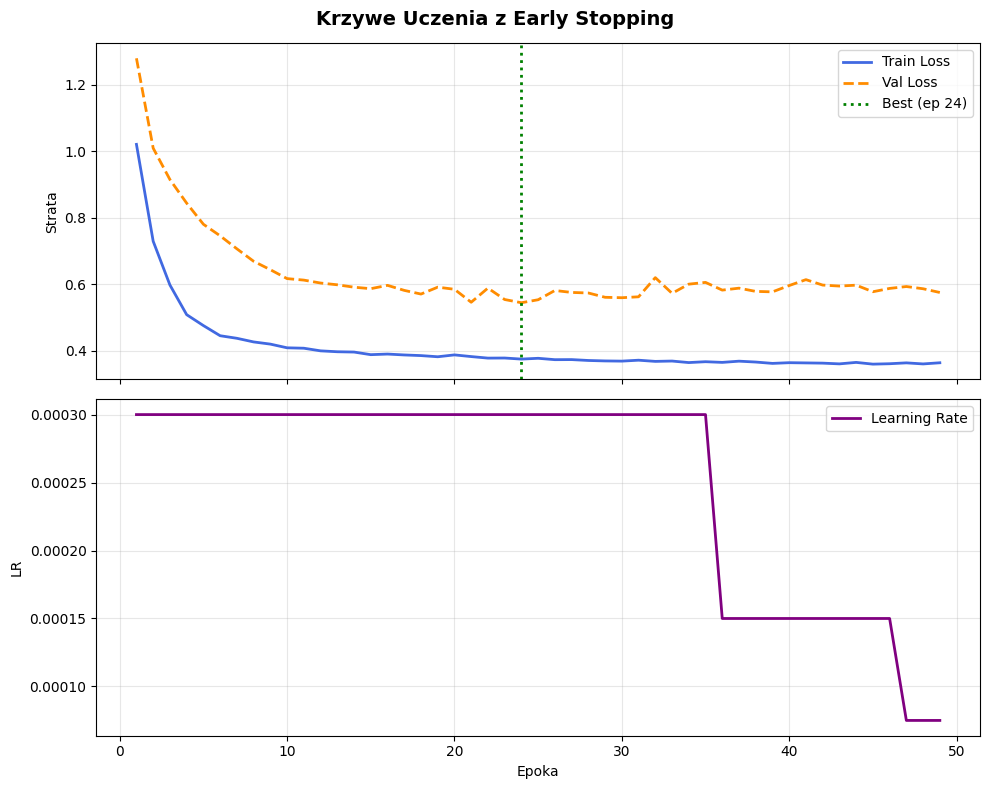


--- KROK 4 ZAKOŃCZONY ---


In [120]:
import torch, torch.nn as nn, torch.optim as optim
import numpy as np, matplotlib.pyplot as plt, copy
from sklearn.utils.class_weight import compute_class_weight

print("="*70)
print("KROK 4: Trening modelu")
print("="*70)

# FUNKCJA TRENINGOWA
def train_model(model, train_loader, val_loader, cfg, device, verbose=True):
    """Trenuje model i zwraca historię + najlepsze wagi."""
    model = model.to(device)

    # Wagi klas
    unikalne = np.unique(Y_clf_train)
    wagi = compute_class_weight("balanced", classes=unikalne, y=Y_clf_train)
    wagi_t = torch.tensor(wagi, dtype=torch.float32).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=cfg.get("lr_factor", 0.5),
        patience=cfg.get("lr_patience", 10)
    )
    crit_mse = nn.MSELoss()
    crit_ce  = nn.CrossEntropyLoss(weight=wagi_t)

    best_val = float("inf")
    best_weights = None
    best_ep = 0
    no_improve = 0
    hist = {"train": [], "val": [], "lr": []}

    for epoch in range(cfg["epochs"]):
        # TRENING
        model.train()
        run_t = 0.0
        for bX, bYr, bYc in train_loader:
            bX, bYr, bYc = bX.to(device), bYr.to(device), bYc.to(device)
            optimizer.zero_grad()
            pr, pc = model(bX)
            loss = cfg["alpha"]*crit_mse(pr, bYr) + cfg["beta"]*crit_ce(pc, bYc)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            run_t += loss.item()
        avg_t = run_t / len(train_loader)

        # WALIDACJA
        model.eval()
        run_v = 0.0
        with torch.no_grad():
            for vX, vYr, vYc in val_loader:
                vX, vYr, vYc = vX.to(device), vYr.to(device), vYc.to(device)
                vpr, vpc = model(vX)
                vl = cfg["alpha"]*crit_mse(vpr, vYr) + cfg["beta"]*crit_ce(vpc, vYc)
                run_v += vl.item()
        avg_v = run_v / len(val_loader)

        lr_now = optimizer.param_groups[0]["lr"]
        hist["train"].append(avg_t)
        hist["val"].append(avg_v)
        hist["lr"].append(lr_now)

        if verbose and ((epoch+1) % 10 == 0 or epoch == 0):
            print(f"Epoka [{epoch+1:03d}/{cfg['epochs']}] | Train: {avg_t:.4f} | Val: {avg_v:.4f} | LR: {lr_now:.2e}")

        scheduler.step(avg_v)

        if avg_v < best_val:
            best_val = avg_v
            best_weights = copy.deepcopy(model.state_dict())
            no_improve = 0
            best_ep = epoch + 1
        else:
            no_improve += 1
            if no_improve >= cfg["patience"]:
                if verbose: print(f"\n[EARLY STOPPING] Epoka {epoch+1}")
                break

    model.load_state_dict(best_weights)
    if verbose: print(f"Najlepszy model: epoka {best_ep}, Val Loss: {best_val:.4f}")
    return model, hist, best_ep, best_val


# TRENING GŁÓWNEGO MODELU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Urządzenie: {device}\n")

CFG = {
    "lr": 3e-4, "weight_decay": 1e-4, "epochs": 200, "patience": 25,
    "alpha": 1.0, "beta": 0.3, "lr_patience": 10, "lr_factor": 0.5,
}

model, history, best_epoch, best_val_loss = train_model(
    model, train_loader, val_loader, CFG, device
)

# DIAGNOSTYKA
gap = history["val"][-1] - history["train"][-1]
print(f"\n--- Diagnostyka ---")
print(f"Train: {history['train'][-1]:.4f} | Val: {history['val'][-1]:.4f} | Gap: {gap:.4f}")
if gap > 0.5: print("⚠ Overfitting")
elif gap < 0: print("⚠ Val < Train — zbiór walidacyjny zbyt łatwy")
else: print("✓ Gap OK")

# WIZUALIZACJA
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
fig.suptitle("Krzywe Uczenia z Early Stopping", fontsize=14, fontweight="bold")
ep_range = range(1, len(history["train"])+1)

ax1.plot(ep_range, history["train"], label="Train Loss", color="royalblue", linewidth=2)
ax1.plot(ep_range, history["val"], label="Val Loss", color="darkorange", linewidth=2, linestyle="--")
ax1.axvline(x=best_epoch, color="green", linestyle=":", linewidth=2, label=f"Best (ep {best_epoch})")
ax1.set_ylabel("Strata"); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(ep_range, history["lr"], label="Learning Rate", color="purple", linewidth=2)
ax2.set_ylabel("LR"); ax2.set_xlabel("Epoka"); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
print("\n--- KROK 4 ZAKOŃCZONY ---")


KROK 5: Ewaluacja i Backtesting

METRYKI REGRESJI (Predykcja ceny)
  MAE:  14128.00 USD
  RMSE: 14649.58 USD
  MAPE: 14.44%

METRYKI KLASYFIKACJI (Sygnały transakcyjne)
              precision    recall  f1-score   support

     HOLD(0)       0.00      0.00      0.00       168
      BUY(1)       0.00      0.00      0.00        85
     SELL(2)       0.22      1.00      0.36        70

    accuracy                           0.22       323
   macro avg       0.07      0.33      0.12       323
weighted avg       0.05      0.22      0.08       323



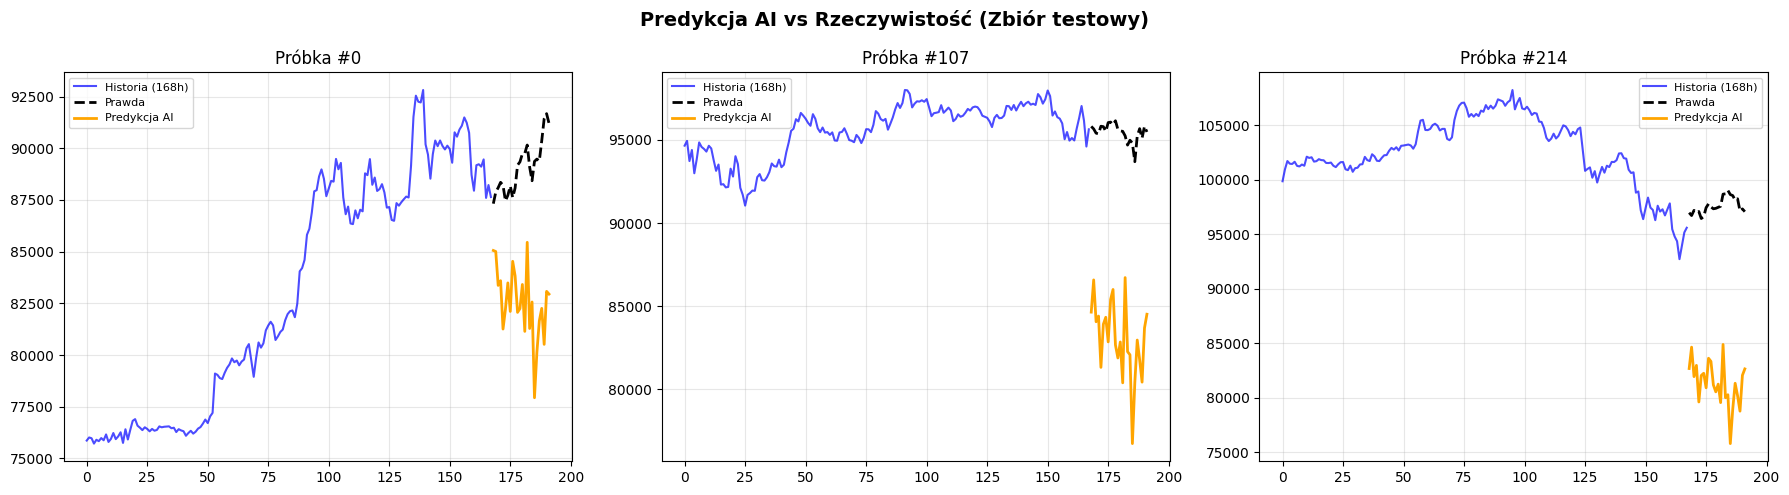


BACKTESTING STRATEGII
Kapitał początkowy:        10000 USD
Kapitał końcowy (AI):      10000.00 USD
Zwrot strategii AI:        0.00%
Zwrot Buy & Hold:          14.11%
Przewaga nad B&H:          -14.11%
Sygnały BUY:  0
Sygnały SELL: 323
Sygnały HOLD: 0
Cena start:  87,644 USD
Cena koniec: 100,012 USD
Max Drawdown:              0.00%


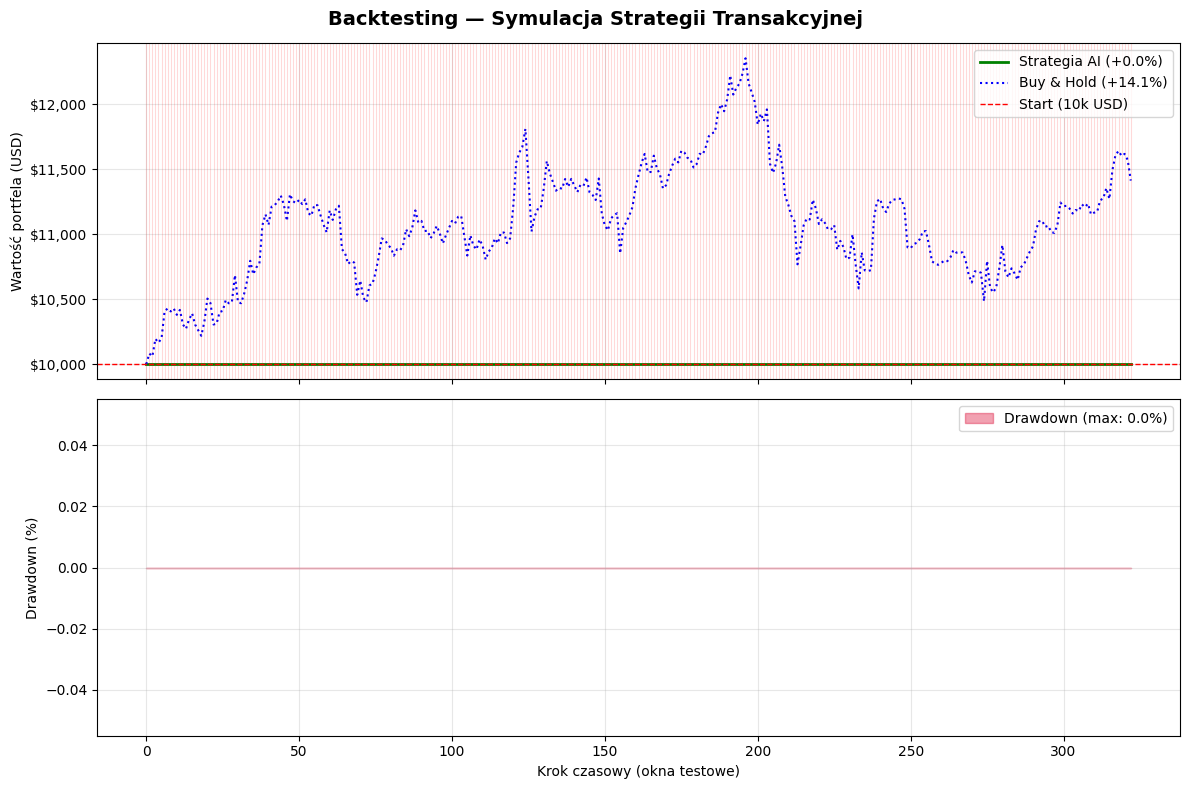


--- KROK 5 ZAKOŃCZONY ---


In [121]:
import torch, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, classification_report

print("="*70)
print("KROK 5: Ewaluacja i Backtesting")
print("="*70)

#ZBIERANIE PREDYKCJI NA ZBIORZE TESTOWYM
model.eval()
all_pr, all_tr, all_pc, all_tc = [], [], [], []

with torch.no_grad():
    for tX, tYr, tYc in test_loader:
        tX = tX.to(device)
        pr, pc = model(tX)
        all_pr.append(pr.cpu().numpy())
        all_tr.append(tYr.numpy())
        all_pc.append(torch.argmax(pc, dim=1).cpu().numpy())
        all_tc.append(tYc.numpy())

preds_reg = np.concatenate(all_pr)
targs_reg = np.concatenate(all_tr)
preds_clf = np.concatenate(all_pc)
targs_clf = np.concatenate(all_tc)

# Odwrócenie skalowania do USD
pred_usd = scaler_Y.inverse_transform(preds_reg.reshape(-1,1)).reshape(preds_reg.shape)
targ_usd = scaler_Y.inverse_transform(targs_reg.reshape(-1,1)).reshape(targs_reg.shape)

#METRYKI REGRESJI
mae  = mean_absolute_error(targ_usd, pred_usd)
rmse = np.sqrt(mean_squared_error(targ_usd, pred_usd))
mape = np.mean(np.abs((targ_usd - pred_usd) / (targ_usd + 1e-8))) * 100

print("\n" + "="*55)
print("METRYKI REGRESJI (Predykcja ceny)")
print(f"  MAE:  {mae:.2f} USD")
print(f"  RMSE: {rmse:.2f} USD")
print(f"  MAPE: {mape:.2f}%")
print("="*55)

#METRYKI KLASYFIKACJI
print("\nMETRYKI KLASYFIKACJI (Sygnały transakcyjne)")
print(classification_report(
    targs_clf, preds_clf, labels=[0,1,2],
    target_names=['HOLD(0)','BUY(1)','SELL(2)'], zero_division=0
))

# WIZUALIZACJA PREDYKCJI vs RZECZYWISTOŚĆ
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Predykcja AI vs Rzeczywistość (Zbiór testowy)", fontsize=14, fontweight='bold')

for idx, ax in enumerate(axes):
    sample_idx = idx * (len(pred_usd) // 3)
    if sample_idx >= len(pred_usd): sample_idx = len(pred_usd) - 1

    # Historia — surowe ceny Close z X_test (nieposkalowane)
    historia = X_test[sample_idx, :, CLOSE_IDX]

    ax.plot(range(ROZMIAR_OKNA), historia,
            label="Historia (168h)", color='blue', alpha=0.7)
    ax.plot(range(ROZMIAR_OKNA, ROZMIAR_OKNA+HORYZONT), targ_usd[sample_idx],
            label="Prawda", color='black', linestyle='--', linewidth=2)
    ax.plot(range(ROZMIAR_OKNA, ROZMIAR_OKNA+HORYZONT), pred_usd[sample_idx],
            label="Predykcja AI", color='orange', linewidth=2)
    ax.set_title(f"Próbka #{sample_idx}")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

#BACKTESTING
print("\n" + "="*55)
print("BACKTESTING STRATEGII")
print("="*55)

kapital_start = 10000.0

# STRATEGIA AI
cena_start  = float(X_test[0,  -1, CLOSE_IDX])
cena_koniec = float(X_test[-1, -1, CLOSE_IDX])

kapital = 0.0
pozycja = kapital_start / cena_start
hist_kap = []

for i in range(len(preds_clf)):
    cena = float(X_test[i, -1, CLOSE_IDX])

    if preds_clf[i] == 1 and kapital > 0:    # BUY — wchodzimy w BTC
        pozycja = kapital / cena
        kapital = 0.0
    elif preds_clf[i] == 2 and pozycja > 0:  # SELL — wychodzimy do USD
        kapital = pozycja * cena
        pozycja = 0.0

    hist_kap.append(kapital + pozycja * cena)

# Zamknij pozycję na końcu
if pozycja > 0:
    hist_kap[-1] = pozycja * cena_koniec

kapital_koniec_ai = hist_kap[-1]
zwrot_ai = (kapital_koniec_ai - kapital_start) / kapital_start * 100
bh_return = (cena_koniec / cena_start - 1) * 100

# STATYSTYKI
print(f"Kapitał początkowy:        {kapital_start:.0f} USD")
print(f"Kapitał końcowy (AI):      {kapital_koniec_ai:.2f} USD")
print(f"Zwrot strategii AI:        {zwrot_ai:.2f}%")
print(f"Zwrot Buy & Hold:          {bh_return:.2f}%")
print(f"Przewaga nad B&H:          {zwrot_ai - bh_return:+.2f}%")
print(f"Sygnały BUY:  {(preds_clf==1).sum()}")
print(f"Sygnały SELL: {(preds_clf==2).sum()}")
print(f"Sygnały HOLD: {(preds_clf==0).sum()}")
print(f"Cena start:  {cena_start:,.0f} USD")
print(f"Cena koniec: {cena_koniec:,.0f} USD")

# Max drawdown
arr  = np.array(hist_kap)
peak = np.maximum.accumulate(arr)
dd   = (arr - peak) / (peak + 1e-8) * 100
print(f"Max Drawdown:              {dd.min():.2f}%")

bh_equity = [kapital_start * (float(X_test[i, -1, CLOSE_IDX]) / cena_start)
             for i in range(len(preds_clf))]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
fig.suptitle("Backtesting — Symulacja Strategii Transakcyjnej", fontsize=14, fontweight='bold')

ax1.plot(hist_kap,  color='green', linewidth=2,   label=f"Strategia AI ({zwrot_ai:+.1f}%)")
ax1.plot(bh_equity, color='blue',  linewidth=1.5, linestyle=':', label=f"Buy & Hold ({bh_return:+.1f}%)")
ax1.axhline(y=kapital_start, color='red', linestyle='--', linewidth=1, label="Start (10k USD)")

# Zaznacz sygnały SELL na wykresie
for i in range(len(preds_clf)):
    if preds_clf[i] == 2:
        ax1.axvline(x=i, color='red',   alpha=0.15, linewidth=0.8)
    elif preds_clf[i] == 1:
        ax1.axvline(x=i, color='green', alpha=0.15, linewidth=0.8)

ax1.set_ylabel("Wartość portfela (USD)")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax1.legend(); ax1.grid(alpha=0.3)

ax2.fill_between(range(len(dd)), dd, 0, color='crimson', alpha=0.4, label=f"Drawdown (max: {dd.min():.1f}%)")
ax2.set_ylabel("Drawdown (%)")
ax2.set_xlabel("Krok czasowy (okna testowe)")
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

print("\n--- KROK 5 ZAKOŃCZONY ---")

KROK 6: Grid Search — Optymalizacja hiperparametrów (pkt 7.1)
Liczba kombinacji: 16

[1/16] {'d_model': 32, 'num_layers': 1, 'dropout': 0.1, 'lr': 0.0001}
  → Val Loss: 0.5962, Test RMSE: 18462 USD, Params: 17,883

[2/16] {'d_model': 32, 'num_layers': 1, 'dropout': 0.1, 'lr': 0.0005}
  → Val Loss: 0.5414, Test RMSE: 17139 USD, Params: 17,883

[3/16] {'d_model': 32, 'num_layers': 1, 'dropout': 0.3, 'lr': 0.0001}
  → Val Loss: 0.4823, Test RMSE: 14615 USD, Params: 17,883

[4/16] {'d_model': 32, 'num_layers': 1, 'dropout': 0.3, 'lr': 0.0005}
  → Val Loss: 0.5020, Test RMSE: 15671 USD, Params: 17,883

[5/16] {'d_model': 32, 'num_layers': 2, 'dropout': 0.1, 'lr': 0.0001}
  → Val Loss: 0.5618, Test RMSE: 17566 USD, Params: 30,587

[6/16] {'d_model': 32, 'num_layers': 2, 'dropout': 0.1, 'lr': 0.0005}
  → Val Loss: 0.7407, Test RMSE: 22631 USD, Params: 30,587

[7/16] {'d_model': 32, 'num_layers': 2, 'dropout': 0.3, 'lr': 0.0001}
  → Val Loss: 0.5321, Test RMSE: 16763 USD, Params: 30,587

[8/16

,d_model,num_layers,dropout,lr,val_loss,test_rmse,best_epoch,n_params
10,64,1,0.3,0.0001,0.477790,13139.458132,59,66459
11,64,1,0.3,0.0005,0.473035,14035.070930,13,66459
2,32,1,0.3,0.0001,0.482271,14614.558769,69,17883
15,64,2,0.3,0.0005,0.515395,15116.035988,13,116443
3,32,1,0.3,0.0005,0.501975,15671.223564,24,17883
14,64,2,0.3,0.0001,0.516258,15733.710560,43,116443
7,32,2,0.3,0.0005,0.481957,16365.925577,11,30587
6,32,2,0.3,0.0001,0.532121,16763.138608,71,30587
1,32,1,0.1,0.0005,0.541369,17139.337677,15,17883
4,32,2,0.1,0.0001,0.561839,17565.672888,53,30587



🏆 Najlepsza konfiguracja:
   d_model=64, layers=1, dropout=0.3, lr=0.0001
   Test RMSE: 13139 USD


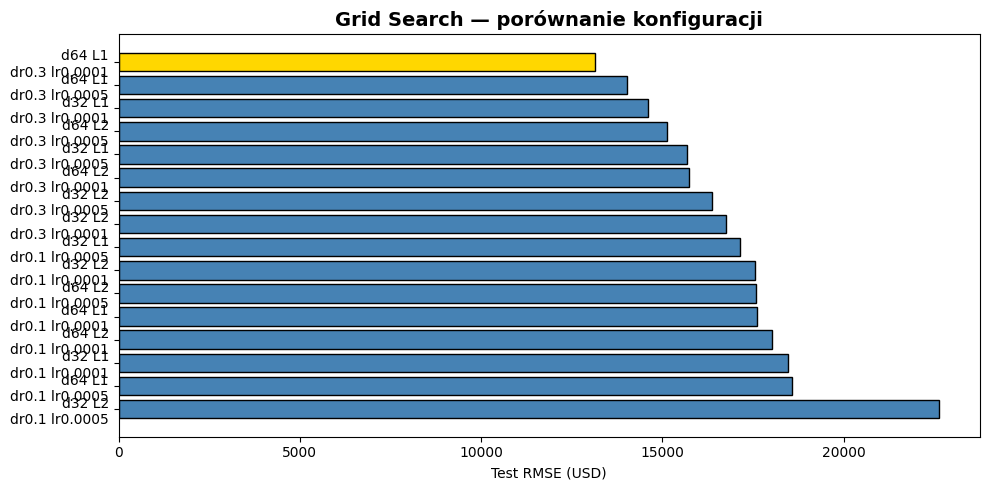


--- KROK 6 ZAKOŃCZONY ---


In [122]:
import itertools, torch, numpy as np, matplotlib.pyplot as plt, copy
from sklearn.metrics import mean_squared_error

print("="*70)
print("KROK 6: Grid Search — Optymalizacja hiperparametrów (pkt 7.1)")
print("="*70)

# SIATKA HIPERPARAMETRÓW
GRID = {
    "d_model":    [32, 64],
    "num_layers": [1, 2],
    "dropout":    [0.1, 0.3],
    "lr":         [1e-4, 5e-4],
}

# Stałe parametry treningu
BASE_CFG = {
    "weight_decay": 1e-4, "epochs": 80, "patience": 15,
    "alpha": 1.0, "beta": 0.3, "lr_patience": 7, "lr_factor": 0.5,
}

keys = list(GRID.keys())
values = list(GRID.values())
combinations = list(itertools.product(*values))
print(f"Liczba kombinacji: {len(combinations)}")

results = []

for idx, combo in enumerate(combinations):
    params = dict(zip(keys, combo))
    print(f"\n[{idx+1}/{len(combinations)}] {params}")

    cfg = {**BASE_CFG, "lr": params["lr"]}

    try:
        m = TransformerForecaster(
            num_features=NUM_FEATURES,
            d_model=params["d_model"],
            nhead=4,
            num_layers=params["num_layers"],
            dropout=params["dropout"],
            horizon=HORYZONT,
        )

        m, hist, best_ep, best_val = train_model(
            m, train_loader, val_loader, cfg, device, verbose=False
        )

        # Szybka ewaluacja RMSE na teście
        m.eval()
        all_p, all_t = [], []
        with torch.no_grad():
            for tX, tYr, tYc in test_loader:
                pr, _ = m(tX.to(device))
                all_p.append(pr.cpu().numpy())
                all_t.append(tYr.numpy())
        p = np.concatenate(all_p)
        t = np.concatenate(all_t)
        p_usd = scaler_Y.inverse_transform(p.reshape(-1,1)).reshape(p.shape)
        t_usd = scaler_Y.inverse_transform(t.reshape(-1,1)).reshape(t.shape)
        rmse = np.sqrt(mean_squared_error(t_usd, p_usd))

        n_params = sum(pp.numel() for pp in m.parameters() if pp.requires_grad)
        results.append({**params, "val_loss": best_val, "test_rmse": rmse,
                        "best_epoch": best_ep, "n_params": n_params})
        print(f"  → Val Loss: {best_val:.4f}, Test RMSE: {rmse:.0f} USD, Params: {n_params:,}")

    except Exception as e:
        print(f"  → BŁĄD: {e}")
        results.append({**params, "val_loss": 999, "test_rmse": 999999,
                        "best_epoch": 0, "n_params": 0})

# TABELA WYNIKÓW
import pandas as pd
df_results = pd.DataFrame(results).sort_values("test_rmse")
print("\n" + "="*70)
print("WYNIKI GRID SEARCH (posortowane wg Test RMSE)")
print("="*70)
display(df_results)

# NAJLEPSZY MODEL
best_config = df_results.iloc[0]
print(f"\n Najlepsza konfiguracja:")
print(f"   d_model={int(best_config['d_model'])}, layers={int(best_config['num_layers'])}, "
      f"dropout={best_config['dropout']}, lr={best_config['lr']}")
print(f"   Test RMSE: {best_config['test_rmse']:.0f} USD")

# WIZUALIZACJA
fig, ax = plt.subplots(figsize=(10, 5))
labels = [f"d{int(r['d_model'])} L{int(r['num_layers'])}\ndr{r['dropout']} lr{r['lr']}"
          for _, r in df_results.iterrows()]
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(labels))]
ax.barh(labels, df_results['test_rmse'].values, color=colors, edgecolor='black')
ax.set_xlabel("Test RMSE (USD)")
ax.set_title("Grid Search — porównanie konfiguracji", fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

print("\n--- KROK 6 ZAKOŃCZONY ---")


KROK 7: Wplyw dlugosci okna wejsciowego (pkt 7.2)

--- Okno: 48h (2d) ---
  MAE: 15720 USD | RMSE: 16209 USD

--- Okno: 96h (4d) ---
  MAE: 18289 USD | RMSE: 18653 USD

--- Okno: 168h (7d) ---
  MAE: 16696 USD | RMSE: 17101 USD

--- Okno: 336h (14d) ---
  MAE: 19026 USD | RMSE: 19380 USD




,okno_h,okno_dni,MAE,RMSE
0,48,2,15720.192383,16208.526645
1,96,4,18289.054688,18653.458661
2,168,7,16696.021484,17101.115753
3,336,14,19025.664062,19380.101135


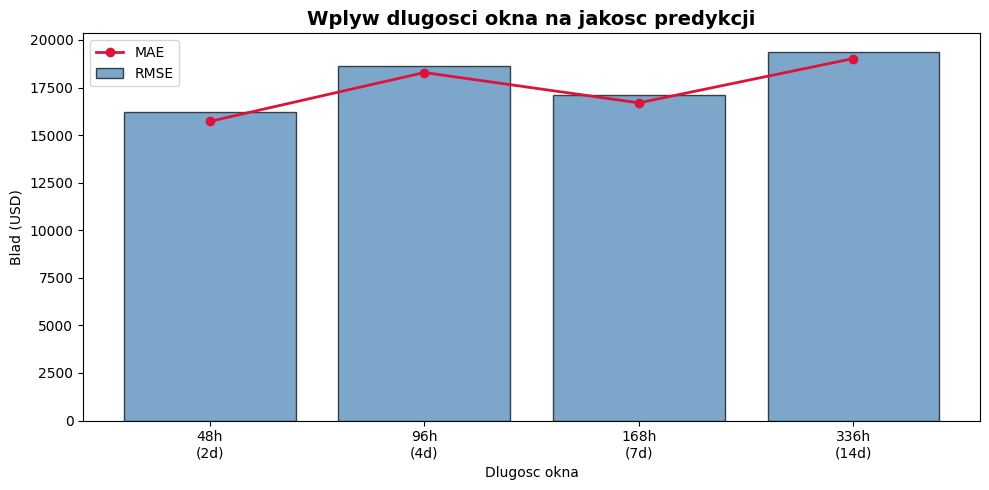


--- KROK 7 ZAKONCZONY ---


In [123]:
import torch, numpy as np, matplotlib.pyplot as plt, pandas as pd
from sklearn.preprocessing import RobustScaler
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("="*70)
print("KROK 7: Wplyw dlugosci okna wejsciowego")
print("="*70)

OKNA = [48, 96, 168, 336]
wyniki = []

for okno in OKNA:
    print(f"\n--- Okno: {okno}h ({okno//24}d) ---")
    Xw, Yr, Yc = [], [], []
    for i in range(0, len(df)-okno-24, 4):
        Xw.append(df[features].iloc[i:i+okno].values)
        Yr.append(df['Close'].iloc[i+okno:i+okno+24].values)
        Yc.append(df['Target_Signal'].iloc[i+okno-1])
    Xw=np.array(Xw); Yr=np.array(Yr); Yc=np.array(Yc,dtype=np.int64)
    n=len(Xw); t1=int(n*0.7); t2=int(n*0.85)

    sx=RobustScaler()
    Xtr=sx.fit_transform(Xw[:t1].reshape(-1,NUM_FEATURES)).reshape(Xw[:t1].shape)
    Xva=sx.transform(Xw[t1:t2].reshape(-1,NUM_FEATURES)).reshape(Xw[t1:t2].shape)
    Xte=sx.transform(Xw[t2:].reshape(-1,NUM_FEATURES)).reshape(Xw[t2:].shape)
    sy=RobustScaler()
    Ytr=sy.fit_transform(Yr[:t1].reshape(-1,1)).reshape(Yr[:t1].shape)
    Yva=sy.transform(Yr[t1:t2].reshape(-1,1)).reshape(Yr[t1:t2].shape)

    trl=DataLoader(TensorDataset(torch.tensor(Xtr,dtype=torch.float32),torch.tensor(Ytr,dtype=torch.float32),torch.tensor(Yc[:t1],dtype=torch.long)),batch_size=32,shuffle=True)
    val=DataLoader(TensorDataset(torch.tensor(Xva,dtype=torch.float32),torch.tensor(Yva,dtype=torch.float32),torch.tensor(Yc[t1:t2],dtype=torch.long)),batch_size=32,shuffle=False)
    tel=DataLoader(TensorDataset(torch.tensor(Xte,dtype=torch.float32),torch.tensor(sy.transform(Yr[t2:].reshape(-1,1)).reshape(Yr[t2:].shape),dtype=torch.float32),torch.tensor(Yc[t2:],dtype=torch.long)),batch_size=32,shuffle=False)

    m=TransformerForecaster(num_features=NUM_FEATURES,d_model=64,nhead=4,num_layers=2,dropout=0.2,horizon=24)
    cfg={"lr":3e-4,"weight_decay":1e-4,"epochs":80,"patience":15,"alpha":1.0,"beta":0.3,"lr_patience":7,"lr_factor":0.5}
    m,_,_,_=train_model(m,trl,val,cfg,device,verbose=False)

    m.eval(); ap,at=[],[]
    with torch.no_grad():
        for tX,tYr,_ in tel:
            pr,_=m(tX.to(device)); ap.append(pr.cpu().numpy()); at.append(tYr.numpy())
    p=np.concatenate(ap); t=np.concatenate(at)
    pu=sy.inverse_transform(p.reshape(-1,1)).reshape(p.shape)
    tu=sy.inverse_transform(t.reshape(-1,1)).reshape(t.shape)
    mae_w=mean_absolute_error(tu,pu); rmse_w=np.sqrt(mean_squared_error(tu,pu))
    wyniki.append({"okno_h":okno,"okno_dni":okno//24,"MAE":mae_w,"RMSE":rmse_w})
    print(f"  MAE: {mae_w:.0f} USD | RMSE: {rmse_w:.0f} USD")

df_o=pd.DataFrame(wyniki)
print("\n"); display(df_o)

fig,ax=plt.subplots(figsize=(10,5))
x=[f"{w['okno_h']}h\n({w['okno_dni']}d)" for w in wyniki]
ax.bar(x,df_o['RMSE'],color='steelblue',alpha=0.7,label='RMSE',edgecolor='black')
ax.plot(x,df_o['MAE'],color='crimson',marker='o',linewidth=2,label='MAE')
ax.set_ylabel("Blad (USD)"); ax.set_xlabel("Dlugosc okna")
ax.set_title("Wplyw dlugosci okna na jakosc predykcji",fontsize=14,fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()
print("\n--- KROK 7 ZAKONCZONY ---")


In [128]:
!pip install gradio -q
import gradio as gr, matplotlib.pyplot as plt, numpy as np, torch

def predict_dashboard(indeks_okna):
    indeks = int(indeks_okna)
    if indeks >= len(X_test): indeks = len(X_test) - 1

    surowe_okno = X_test[indeks]
    okno_scaled = scaler_X.transform(surowe_okno)
    tensor_in = torch.tensor(okno_scaled, dtype=torch.float32).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        pred_reg, pred_clf = model(tensor_in)

    pred_ceny = scaler_Y.inverse_transform(pred_reg.cpu().numpy().reshape(-1,1)).flatten()
    prawdziwe_ceny = Y_reg_test[indeks]
    historia_close = surowe_okno[:, CLOSE_IDX]

    # Sygnał
    probs = torch.softmax(pred_clf, dim=1).cpu().numpy()[0]
    sygnal = torch.argmax(pred_clf, dim=1).item()
    pewnosc = probs[sygnal] * 100

    sygnal_map = {0: "⚪ CZEKAJ (HOLD)", 1: "🟢 KUPUJ (BUY)", 2: "🔴 SPRZEDAJ (SELL)"}
    sygnal_tekst = f"{sygnal_map[sygnal]}\nPewność: {pewnosc:.1f}%"
    sygnal_tekst += f"\n\nPrawdopodobieństwa:"
    sygnal_tekst += f"\n  HOLD: {probs[0]*100:.1f}%"
    sygnal_tekst += f"\n  BUY:  {probs[1]*100:.1f}%"
    sygnal_tekst += f"\n  SELL: {probs[2]*100:.1f}%"

    # Metryki
    mae_sample = np.mean(np.abs(prawdziwe_ceny - pred_ceny))
    sygnal_tekst += f"\n\nMAE próbki: {mae_sample:.0f} USD"

    # Wykres
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(range(ROZMIAR_OKNA), historia_close,
            label="Historia (168h)", color='dodgerblue', linewidth=1.5)
    ax.plot(range(ROZMIAR_OKNA, ROZMIAR_OKNA+HORYZONT), prawdziwe_ceny,
            label="Prawdziwa przyszłość", color='black', linestyle='--', linewidth=2)
    ax.plot(range(ROZMIAR_OKNA, ROZMIAR_OKNA+HORYZONT), pred_ceny,
            label="Predykcja AI", color='orange', linewidth=2.5)

    # Kolorowe tło
    color_bg = {0: '#EEEEEE', 1: '#E8F5E9', 2: '#FFEBEE'}
    ax.axvspan(ROZMIAR_OKNA, ROZMIAR_OKNA+HORYZONT, alpha=0.15, color=color_bg[sygnal])

    ax.set_title(f"Transformer: 168h wejścia → 24h predykcji (Próbka #{indeks})",
                 fontsize=13, fontweight='bold')
    ax.set_xlabel("Kroki czasowe (Godziny)")
    ax.set_ylabel("Cena BTC/USDT (USD)")
    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)
    plt.tight_layout()

    return fig, sygnal_tekst

# BUDOWA INTERFEJSU
with gr.Blocks(title="AI Crypto Forecaster") as app:
    gr.Markdown("# 🤖 AI Crypto Forecaster (Transformer)")
    gr.Markdown("Wybierz indeks okna ze zbioru testowego, aby zobaczyć predykcję modelu.")

    with gr.Row():
        slider = gr.Slider(0, len(X_test)-1, step=1, label="Wycinek czasu (Indeks)", value=0)
        btn = gr.Button("Analizuj Rynek", variant="primary")

    with gr.Row():
        wykres = gr.Plot(label="Wizualizacja Predykcji")
        sygnal = gr.Textbox(label="Decyzja Algorytmu", lines=10)

    btn.click(fn=predict_dashboard, inputs=slider, outputs=[wykres, sygnal])

app.launch(share=True, debug=False)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://660b7b15aae71dc208.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
